# WISDM Dataset 기반 CNN+GRU 분류

### 결과 분석

CCN3 + GRU1 Test accuracy: 94.29%

CCN4 + GRU1 Test accuracy: 86.31%


WISDM 데이터셋을 CNN+GRU 기반 모델로 학습한 결과 정확도는 일반 CNN3를 구성한 결과랑 비슷하게 나타났다.

CNN은 센서 신호의 짧은 구간에서 나타나는 움직임 패턴을 추출하고 GRU는 추출된 feature의 시간적 흐름을 학습한다.

하지만 WISDM 데이터는 시간적 흐름보다는 짧은 구간에서 나타나는 움직임 패턴이 더 많이 포함되어 있기 때문에 앞에서 실험한 CNN3의 정확도와 큰 차이를 보이지 못해 WISDM에서는 GRU가 성능 향상에 기여를 못한 것으로 판단된다.

따라서 WISDM 데이터셋에서는 GRU를 추가한 구조보다 CNN을 깊게 쌓은 CNN4 구조가 더 효과적이라고 볼 수 있다.








In [12]:
# 라이브러리 import
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, GRU, BatchNormalization, ReLU, MaxPool1D,
    GlobalAveragePooling1D, Dense, Dropout
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [13]:
# 구글 드라이브 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
# 경로 정의
DATASET_PATH = "/content/drive/MyDrive/WISDM_ar_v1.1_raw.txt"

## 데이터 전처리

1. **raw 데이터 로드**
2. **클린업** : 마지막 NaN 컬럼 제거, 결측 행 dropna, z_axis의 `;` 제거 후 float 변환
3. **Label Encoding** : LabelEncoder로 activity -> 정수
4. **Data Split (user_id 기반)** :
  - user_id ≤ 26
  - 27 ≤ user_id ≤ 31
  - user_id ≥ 32
5. **정규화** : StandardScaler를 train에서 fit, val/test는 transform만
6. **Segmentation** : sliding window (TIME_STEPS=200, STEP=40)

In [15]:
# raw 데이터 로드
# WISDM raw data는 컬럼명이 없는 형태
# 각 칼럼에 이름 지정
names = ["user_id", "activity", "timestamp", "x_axis", "y_axis", "z_axis", "NaN"]
data = pd.read_csv(DATASET_PATH, header=None, names=names, comment=";") # 세미콜론 이후 내용 무시
print(data.head())


   user_id activity       timestamp    x_axis     y_axis    z_axis  NaN
0       33  Jogging  49105962326000 -0.694638  12.680544  0.503953  NaN
1       33  Jogging  49106062271000  5.012288  11.264028  0.953424  NaN
2       33  Jogging  49106112167000  4.903325  10.882658 -0.081722  NaN
3       33  Jogging  49106222305000 -0.612916  18.496431  3.023717  NaN
4       33  Jogging  49106332290000 -1.184970  12.108489  7.205164  NaN


In [16]:
# 클린업
# 문자열 값을 float32 숫자형으로 변환
def convert_to_float(x):
    try:
        return np.float32(x)
    except:
        return np.nan

# 앞에서 raw data를 읽을 때 생긴 불필요한 NaN 컬럼 제거
df = data.drop('NaN', axis=1)
# 결측값 행 제거
df = df.dropna()

# 세미콜론 제거
df["z_axis"] = df["z_axis"].replace(regex=True, to_replace=r';', value=r'')
# x, y, z축 가속도 값을 문자열에서 float32 숫자형으로 변환
df["x_axis"] = df["x_axis"].apply(convert_to_float)
df["y_axis"] = df["y_axis"].apply(convert_to_float)
df["z_axis"] = df["z_axis"].apply(convert_to_float)
df = df.dropna()
df.info()

print("\nActivity counts:")
print(df['activity'].value_counts())


<class 'pandas.core.frame.DataFrame'>
Index: 1098203 entries, 0 to 1098203
Data columns (total 6 columns):
 #   Column     Non-Null Count    Dtype  
---  ------     --------------    -----  
 0   user_id    1098203 non-null  int64  
 1   activity   1098203 non-null  object 
 2   timestamp  1098203 non-null  int64  
 3   x_axis     1098203 non-null  float32
 4   y_axis     1098203 non-null  float32
 5   z_axis     1098203 non-null  float32
dtypes: float32(3), int64(2), object(1)
memory usage: 46.1+ MB

Activity counts:
activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


In [17]:
# Label Encoding
label_encoder = LabelEncoder()
df['activity_encoded'] = label_encoder.fit_transform(df['activity'])
num_classes = len(label_encoder.classes_)
print("\nLabel mapping:", dict(enumerate(label_encoder.classes_)))



Label mapping: {0: 'Downstairs', 1: 'Jogging', 2: 'Sitting', 3: 'Standing', 4: 'Upstairs', 5: 'Walking'}


In [18]:
# Data Split (user_id 기반)
# user_id가 26 이하 = train set
df_train = df[df['user_id'] <= 26]
# user_id가 27~31인 = validation set
df_val   = df[(df['user_id'] > 26) & (df['user_id'] < 32)]
# user_id가 32 이상 = test set
df_test  = df[df['user_id'] >= 32]

print(f"\nTrain users: {sorted(df_train['user_id'].unique())}")
print(f"Val   users: {sorted(df_val['user_id'].unique())}")
print(f"Test  users: {sorted(df_test['user_id'].unique())}")



Train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26)]
Val   users: [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31)]
Test  users: [np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


In [19]:
# 정규화
scaler = StandardScaler()
df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']] = scaler.fit_transform(df_train.loc[:, ['x_axis', 'y_axis', 'z_axis']])
df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_val.loc[:,   ['x_axis', 'y_axis', 'z_axis']])
df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']] = scaler.transform(df_test.loc[:,  ['x_axis', 'y_axis', 'z_axis']])


In [20]:
# Segmentation (Sliding Window)
# 연속된 센서 데이터를 고정 길이 window로 분할
def create_dataset(x, y, time_steps=200, step=40):
    xs, ys = [], []
    # 전체 데이터를 time_steps 길이만큼 자르고 step 간격으로 이동
    for i in range(0, len(x) - time_steps, step):
        # 현재 window에 해당하는 x/y/z 센서 값 추출
        v = x.iloc[i:i + time_steps].values
        # 현재 window 안에 포함된 activity label 추출
        labels = y.iloc[i:i + time_steps]
        # window 내부에서 가장 많이 등장한 label을 대표 label로 사용
        values, counts = np.unique(labels, return_counts=True)
        mode_label = values[np.argmax(counts)]
        xs.append(v)
        ys.append(mode_label)
    return np.array(xs), np.array(ys)

TIME_STEPS = 200
STEP = 40
x_train, y_train = create_dataset(df_train[['x_axis', 'y_axis', 'z_axis']], df_train['activity_encoded'], TIME_STEPS, STEP)
x_val,   y_val   = create_dataset(df_val[['x_axis', 'y_axis', 'z_axis']],   df_val['activity_encoded'],   TIME_STEPS, STEP)
x_test,  y_test  = create_dataset(df_test[['x_axis', 'y_axis', 'z_axis']],  df_test['activity_encoded'],  TIME_STEPS, STEP)

print(f"\nx_train: {x_train.shape}, y_train: {y_train.shape}")
print(f"x_val  : {x_val.shape},  y_val  : {y_val.shape}")
print(f"x_test : {x_test.shape},  y_test : {y_test.shape}")


x_train: (19457, 200, 3), y_train: (19457,)
x_val  : (4100, 200, 3),  y_val  : (4100,)
x_test : (3885, 200, 3),  y_test : (3885,)


In [21]:
# 클래스 가중치 (불균형 보정)
# 모델이 적은 class도 무시하지 않도록 만드는 역할
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print("Class weights:", class_weights_dict)

Class weights: {0: np.float64(1.899726615895333), 1: np.float64(0.5175284604745186), 2: np.float64(3.272283888328288), 3: np.float64(4.244546247818499), 4: np.float64(1.4834553217444342), 5: np.float64(0.429912943567988)}


## CNN 3 (Conv1D 3개) + GRU 1


In [22]:
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model1 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GRU(64, return_sequences=False, dropout=0.2),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model1.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 64)             │        61,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,998 (769.52 KB)

 Trainable params: 196,102 (766.02 KB)

 Non-trainable params: 896 (3.50 KB)

None


In [23]:
callbacks1 = [
    ModelCheckpoint(
        "WISDM_HAR_CNN3_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history1 = model1.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks1,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.7477 - sparse_categorical_accuracy: 0.7133
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.75878, saving model to WISDM_HAR_CNN3_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - loss: 0.4787 - sparse_categorical_accuracy: 0.8373 - val_loss: 0.9720 - val_sparse_categorical_accuracy: 0.7588 - learning_rate: 0.0010
Epoch 2/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1442 - sparse_categorical_accuracy: 0.9636
Epoch 2: val_sparse_categorical_accuracy improved from 0.75878 to 0.80951, saving model to WISDM_HAR_CNN3_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1285 - sparse_categorical_accuracy: 0.9661 - val_loss: 0.8026 - val_sparse_categorical_accuracy: 0.8095 - learning_rate: 0.0010
Epoch 3/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.1448 - sparse_categorical_accuracy: 0.9619
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.80951
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.1170 - sparse_categorical_accuracy: 0.9702 - val_loss: 0.8868 - val_sparse_categorical_accuracy: 0.8032 - learning_rate: 0.0010
Epoch 4/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1181 - sparse_categorical_accuracy: 0.9649
Epoch 4: val_sparse_categorical_accuracy did not improve from 0.80951
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0851 - sparse_categorical_accuracy: 0.9760 - val_loss: 1.2525 - val_sparse_categorical_accuracy: 0.7985 - learning_rate: 0.0010
Epoch 5/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms


Epoch 5: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0608 - sparse_categorical_accuracy: 0.9845 - val_loss: 1.0906 - val_sparse_categorical_accuracy: 0.8117 - learning_rate: 0.0010
Epoch 6/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0503 - sparse_categorical_accuracy: 0.9861
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.81171
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0523 - sparse_categorical_accuracy: 0.9866 - val_loss: 0.7266 - val_sparse_categorical_accuracy: 0.8083 - learning_rate: 0.0010
Epoch 7/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1518 - sparse_categorical_accuracy: 0.9595
Epoch 7: val_sparse_categorical_accuracy did not improve from 0.81171
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0907 - sparse_categorical_accuracy: 0.9761 - val_loss: 1.1347 - val_sparse_categorical_accuracy: 0.8054 - learning_rate: 0.0010
Epoch 8/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms


Epoch 8: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - loss: 0.0570 - sparse_categorical_accuracy: 0.9864 - val_loss: 0.9782 - val_sparse_categorical_accuracy: 0.8171 - learning_rate: 0.0010
Epoch 9/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2450 - sparse_categorical_accuracy: 0.9439
Epoch 9: val_sparse_categorical_accuracy did not improve from 0.81707
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1291 - sparse_categorical_accuracy: 0.9677 - val_loss: 1.0979 - val_sparse_categorical_accuracy: 0.8168 - learning_rate: 0.0010
Epoch 10/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2127 - sparse_categorical_accuracy: 0.9144
Epoch 10: val_sparse_categorical_accuracy improved from 0.81707 to 0.82732, saving model to WISDM_HAR_CNN3_best.h5



Epoch 10: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.1180 - sparse_categorical_accuracy: 0.9602 - val_loss: 1.1774 - val_sparse_categorical_accuracy: 0.8273 - learning_rate: 0.0010
Epoch 11/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0573 - sparse_categorical_accuracy: 0.9868
Epoch 11: val_sparse_categorical_accuracy improved from 0.82732 to 0.82976, saving model to WISDM_HAR_CNN3_best.h5



Epoch 11: finished saving model to WISDM_HAR_CNN3_best.h5

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0517 - sparse_categorical_accuracy: 0.9867 - val_loss: 1.1461 - val_sparse_categorical_accuracy: 0.8298 - learning_rate: 0.0010
Epoch 12/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0400 - sparse_categorical_accuracy: 0.9888
Epoch 12: val_sparse_categorical_accuracy improved from 0.82976 to 0.83122, saving model to WISDM_HAR_CNN3_best.h5



Epoch 12: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 0.0375 - sparse_categorical_accuracy: 0.9903 - val_loss: 1.1035 - val_sparse_categorical_accuracy: 0.8312 - learning_rate: 5.0000e-04
Epoch 13/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0301 - sparse_categorical_accuracy: 0.9915
Epoch 13: val_sparse_categorical_accuracy did not improve from 0.83122
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0322 - sparse_categorical_accuracy: 0.9911 - val_loss: 1.0660 - val_sparse_categorical_accuracy: 0.8288 - learning_rate: 5.0000e-04
Epoch 14/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0612 - sparse_categorical_accuracy: 0.9850
Epoch 14: val_sparse_categorical_accuracy improved from 0.83122 to 0.83268, saving model to WISDM_HAR_CNN3_best.h5



Epoch 14: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0445 - sparse_categorical_accuracy: 0.9881 - val_loss: 1.0999 - val_sparse_categorical_accuracy: 0.8327 - learning_rate: 5.0000e-04
Epoch 15/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0333 - sparse_categorical_accuracy: 0.9907
Epoch 15: val_sparse_categorical_accuracy did not improve from 0.83268
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0313 - sparse_categorical_accuracy: 0.9913 - val_loss: 1.1510 - val_sparse_categorical_accuracy: 0.8222 - learning_rate: 5.0000e-04
Epoch 16/100
302/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0325 - sparse_categorical_accuracy: 0.9899
Epoch 16: val_sparse_categorical_accuracy did not improve from 0.83268

Epoch 16: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0317 - sparse_categorical_accuracy: 0.9911 - val_loss: 0.9636 - val_sparse_categorica


Epoch 19: finished saving model to WISDM_HAR_CNN3_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 0.0211 - sparse_categorical_accuracy: 0.9944 - val_loss: 1.0997 - val_sparse_categorical_accuracy: 0.8354 - learning_rate: 2.5000e-04
Epoch 20/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0169 - sparse_categorical_accuracy: 0.9951
Epoch 20: val_sparse_categorical_accuracy did not improve from 0.83537
305/305 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0191 - sparse_categorical_accuracy: 0.9947 - val_loss: 1.0964 - val_sparse_categorical_accuracy: 0.8290 - learning_rate: 2.5000e-04
Epoch 21/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0188 - sparse_categorical_accuracy: 0.9937
Epoch 21: val_sparse_categorical_accuracy did not improve from 0.83537

Epoch 21: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
305/305 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - loss: 0.0189 - sparse_categorical_accuracy: 0.9949 - val_loss: 1.1323 - val_sparse_categorica

In [24]:
# 모델 평가
model1 = tf.keras.models.load_model("WISDM_HAR_CNN3_best.h5")

train_loss, train_acc = model1.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model1.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 99.73%
Training loss: 0.0087
Test accuracy: 94.29%
Test loss: 0.3161


In [25]:
y_pred_proba = model1.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.7975    0.9220    0.8552       346
     Jogging     0.9913    0.9544    0.9725      1316
     Sitting     0.9836    0.9967    0.9901       300
    Standing     0.9936    0.8201    0.8986       189
    Upstairs     0.8329    0.7656    0.7978       384
     Walking     0.9537    0.9926    0.9728      1350

    accuracy                         0.9429      3885
   macro avg     0.9254    0.9086    0.9145      3885
weighted avg     0.9448    0.9429    0.9427      3885



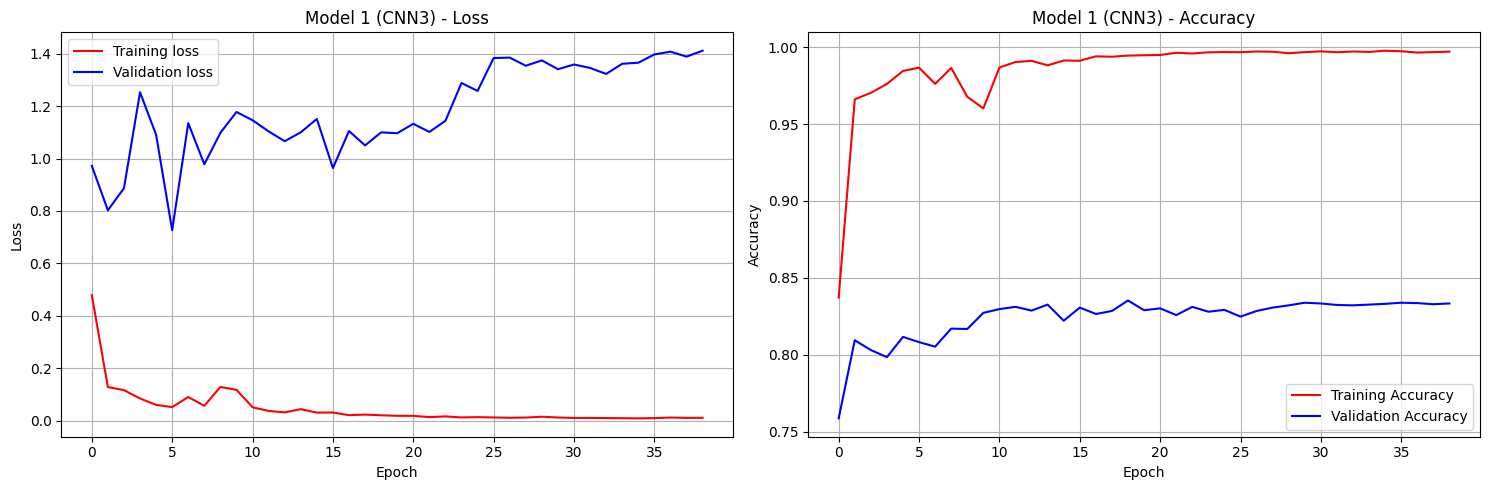

In [26]:
train_loss = history1.history['loss']
train_accuracy = history1.history['sparse_categorical_accuracy']
val_loss = history1.history['val_loss']
val_accuracy = history1.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Model 1 (CNN3) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Model 1 (CNN3) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

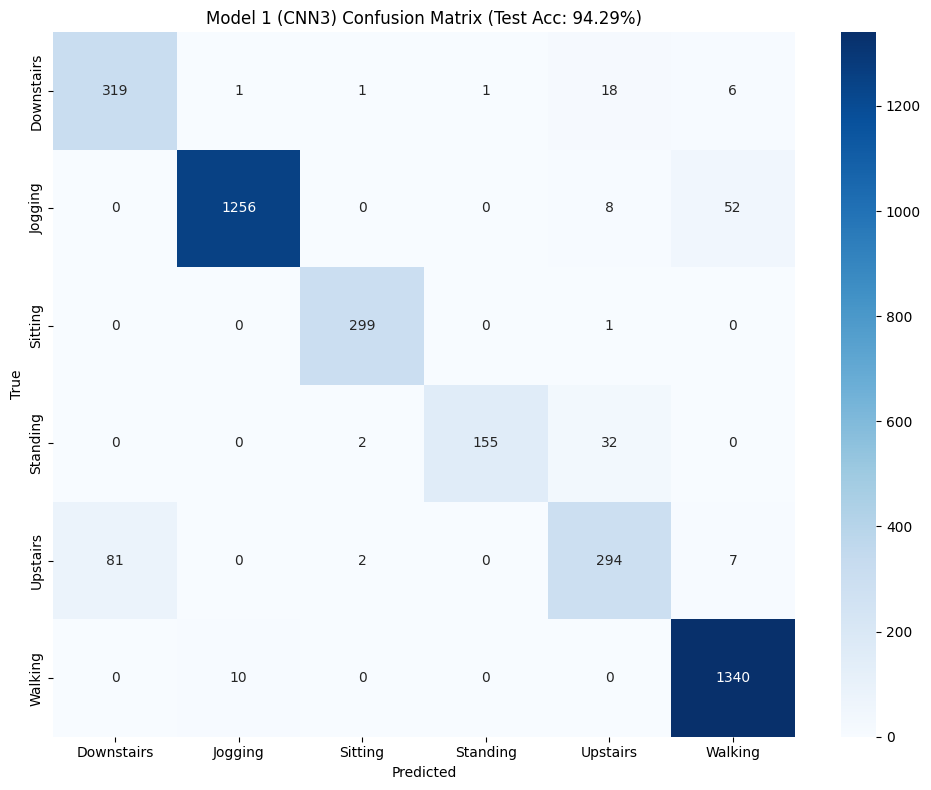

In [27]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 1 (CNN3) Confusion Matrix (Test Acc: {test_acc * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

## CNN4+GRU1 Model

In [28]:
input_shape = (x_train.shape[1], x_train.shape[2])
num_classes = len(label_encoder.classes_)

model2 = Sequential([
    Input(shape=input_shape),

    Conv1D(64, 5, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(128, 3, padding='same'),
    BatchNormalization(),
    ReLU(),
    MaxPool1D(),

    Conv1D(256, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    Conv1D(512, 3, padding='same'),
    BatchNormalization(),
    ReLU(),

    GRU(64, return_sequences=False, dropout=0.2),

    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model2.summary())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)               │ (None, 200, 64)        │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 200, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_6 (ReLU)                  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 200, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 100, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 100, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_8 (ReLU)                  │ (None, 100, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 100, 512)       │       393,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100, 512)       │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_9 (ReLU)                  │ (None, 100, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │       110,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 651,014 (2.48 MB)

 Trainable params: 649,094 (2.48 MB)

 Non-trainable params: 1,920 (7.50 KB)

None


In [29]:
callbacks2 = [
    ModelCheckpoint(
        "WISDM_HAR_CNN4_GRU1_best.h5",
        save_best_only=True,
        monitor="val_sparse_categorical_accuracy",
        mode='max',
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_sparse_categorical_accuracy",
        patience=20,
        verbose=1,
        mode='max',
        restore_best_weights=True
    )
]

history2 = model2.fit(
    x_train, y_train,
    epochs=100,
    batch_size=64,
    validation_data=(x_val, y_val),
    callbacks=callbacks2,
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.6413 - sparse_categorical_accuracy: 0.7637
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.80317, saving model to WISDM_HAR_CNN4_GRU1_best.h5



Epoch 1: finished saving model to WISDM_HAR_CNN4_GRU1_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - loss: 0.3715 - sparse_categorical_accuracy: 0.8753 - val_loss: 0.7953 - val_sparse_categorical_accuracy: 0.8032 - learning_rate: 0.0010
Epoch 2/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.1196 - sparse_categorical_accuracy: 0.9704
Epoch 2: val_sparse_categorical_accuracy improved from 0.80317 to 0.82512, saving model to WISDM_HAR_CNN4_GRU1_best.h5



Epoch 2: finished saving model to WISDM_HAR_CNN4_GRU1_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1164 - sparse_categorical_accuracy: 0.9717 - val_loss: 0.6751 - val_sparse_categorical_accuracy: 0.8251 - learning_rate: 0.0010
Epoch 3/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1108 - sparse_categorical_accuracy: 0.9765
Epoch 3: val_sparse_categorical_accuracy did not improve from 0.82512
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0895 - sparse_categorical_accuracy: 0.9783 - val_loss: 0.9528 - val_sparse_categorical_accuracy: 0.8161 - learning_rate: 0.0010
Epoch 4/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0989 - sparse_categorical_accuracy: 0.9728
Epoch 4: val_sparse_categorical_accuracy improved from 0.82512 to 0.82951, saving model to WISDM_HAR_CNN4_GRU1_best.h5



Epoch 4: finished saving model to WISDM_HAR_CNN4_GRU1_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0828 - sparse_categorical_accuracy: 0.9785 - val_loss: 0.7314 - val_sparse_categorical_accuracy: 0.8295 - learning_rate: 0.0010
Epoch 5/100
303/305 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0485 - sparse_categorical_accuracy: 0.9876
Epoch 5: val_sparse_categorical_accuracy did not improve from 0.82951
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0507 - sparse_categorical_accuracy: 0.9872 - val_loss: 0.8326 - val_sparse_categorical_accuracy: 0.7954 - learning_rate: 0.0010
Epoch 6/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0686 - sparse_categorical_accuracy: 0.9775
Epoch 6: val_sparse_categorical_accuracy did not improve from 0.82951
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0583 - sparse_categorical_accuracy: 0.9841 - val_loss: 1.2669 - val_sparse_categorical_accuracy: 0.8293 - learning_rate: 0.0010
Epoch 7/100
305/305 ━━━━━━━━━━━━━━━━━━━━ 0s


Epoch 7: finished saving model to WISDM_HAR_CNN4_GRU1_best.h5
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.0474 - sparse_categorical_accuracy: 0.9883 - val_loss: 0.5896 - val_sparse_categorical_accuracy: 0.8578 - learning_rate: 0.0010
Epoch 8/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0344 - sparse_categorical_accuracy: 0.9921
Epoch 8: val_sparse_categorical_accuracy did not improve from 0.85780
305/305 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - loss: 0.0436 - sparse_categorical_accuracy: 0.9895 - val_loss: 0.9653 - val_sparse_categorical_accuracy: 0.8180 - learning_rate: 0.0010
Epoch 9/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0350 - sparse_categorical_accuracy: 0.9909
Epoch 9: val_sparse_categorical_accuracy did not improve from 0.85780
305/305 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0384 - sparse_categorical_accuracy: 0.9905 - val_loss: 0.8448 - val_sparse_categorical_accuracy: 0.8290 - learning_rate: 0.0010
Epoch 10/100
304/305 ━━━━━━━━━━━━━━━━━━━━ 

In [30]:
# 모델 평가
model2 = tf.keras.models.load_model("WISDM_HAR_CNN4_GRU1_best.h5")

train_loss2, train_acc2 = model2.evaluate(x_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc2 * 100:.2f}%")
print(f"Training loss: {train_loss2:.4f}")

test_loss2, test_acc2 = model2.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc2 * 100:.2f}%")
print(f"Test loss: {test_loss2:.4f}")

Training accuracy: 99.18%
Training loss: 0.0263
Test accuracy: 86.31%
Test loss: 0.4678


In [31]:
y_pred_proba2 = model2.predict(x_test, verbose=0)
y_pred2 = np.argmax(y_pred_proba2, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=label_encoder.classes_, digits=4))


Classification Report:
              precision    recall  f1-score   support

  Downstairs     0.6596    0.8960    0.7598       346
     Jogging     0.9972    0.8040    0.8902      1316
     Sitting     0.9836    0.9967    0.9901       300
    Standing     0.9891    0.9630    0.9759       189
    Upstairs     0.4930    0.8307    0.6188       384
     Walking     0.9721    0.8778    0.9225      1350

    accuracy                         0.8631      3885
   macro avg     0.8491    0.8947    0.8595      3885
weighted avg     0.9071    0.8631    0.8749      3885



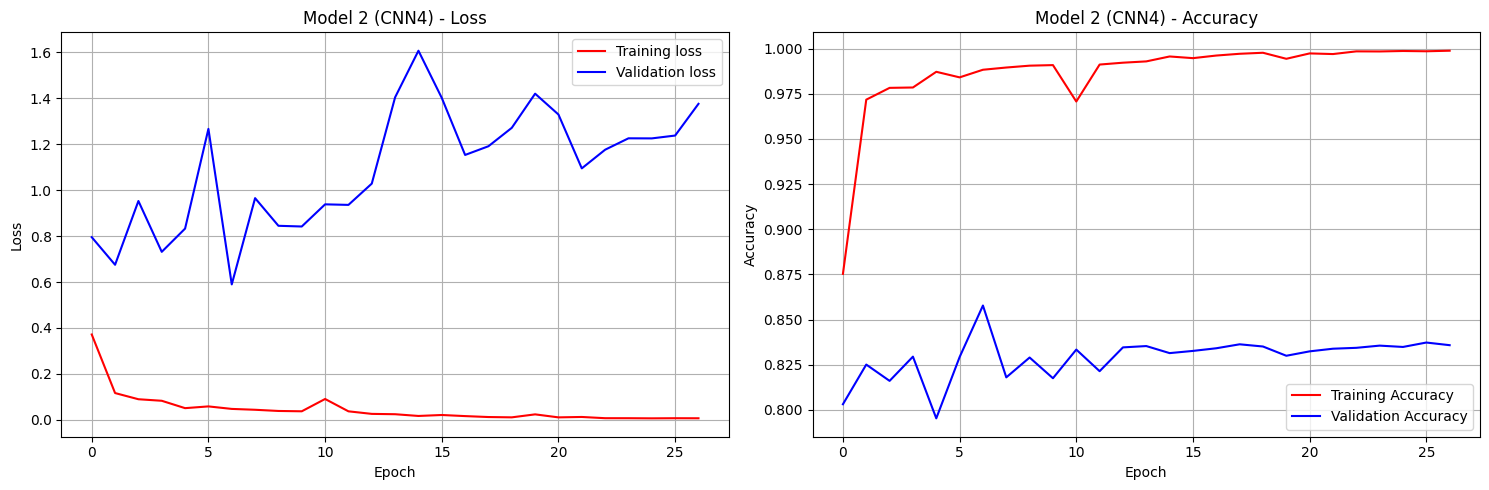

In [32]:
train_loss_h2 = history2.history['loss']
train_accuracy_h2 = history2.history['sparse_categorical_accuracy']
val_loss_h2 = history2.history['val_loss']
val_accuracy_h2 = history2.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss_h2, 'r', label='Training loss')
plt.plot(val_loss_h2, 'b', label='Validation loss')
plt.title('Model 2 (CNN4) - Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(train_accuracy_h2, 'r', label='Training Accuracy')
plt.plot(val_accuracy_h2, 'b', label='Validation Accuracy')
plt.title('Model 2 (CNN4) - Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

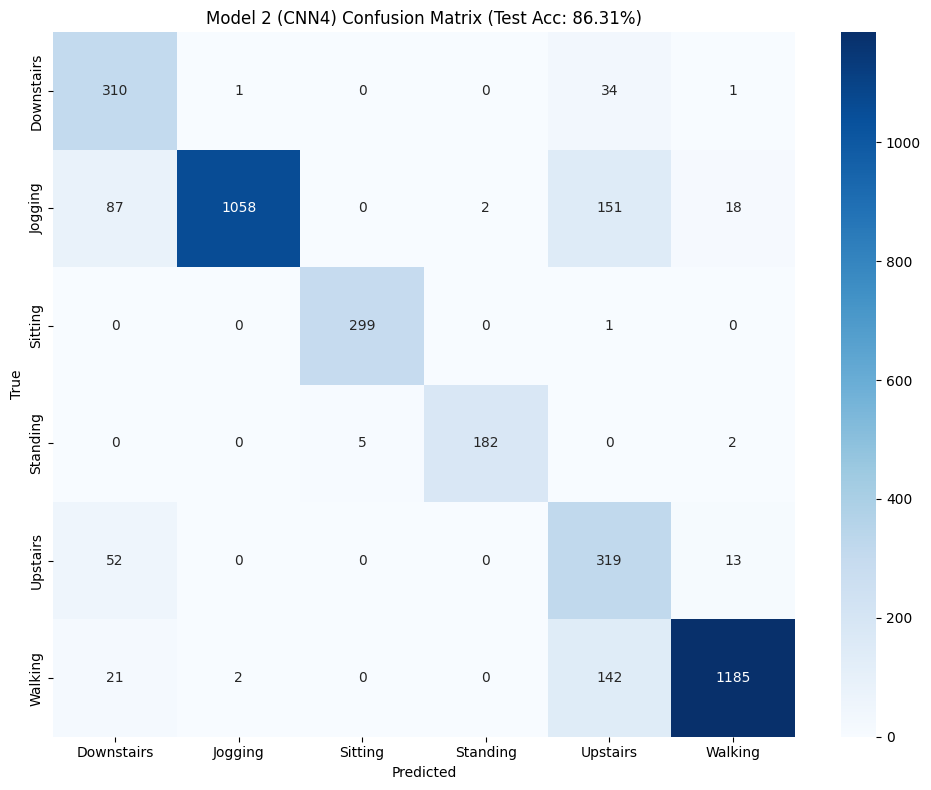

In [33]:
cm2 = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title(f'Model 2 (CNN4) Confusion Matrix (Test Acc: {test_acc2 * 100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()